# Pattern Recognition

In this lab you will experiment with two classic pattern recognition algorithms: Hough Transform (pronounced "huff") and Random Sample Consensus (RANSAC).

Our goal will be to estimate a 2D translational movement of the camera from SIFT feature correspondences.

In [1]:
import matplotlib.pyplot as plt

import numpy as np
import imageio
import skimage
from skimage.color import rgb2gray
from skimage.feature import match_descriptors, plot_matched_features, SIFT

First we load the two book images, extract SIFT features and match them.

In [2]:
img1 = rgb2gray(imageio.imread('book1.jpg'))
img2 = rgb2gray(imageio.imread('book2.jpg'))

C:\tmp\ipykernel_31252\2952376325.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img1 = rgb2gray(imageio.imread('book1.jpg'))
C:\tmp\ipykernel_31252\2952376325.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img2 = rgb2gray(imageio.imread('book2.jpg'))


In [3]:
descriptor_extractor = SIFT()

In [4]:
descriptor_extractor.detect_and_extract(img1)
keypoints1 = descriptor_extractor.keypoints
descriptors1 = descriptor_extractor.descriptors

In [5]:
descriptor_extractor.detect_and_extract(img2)
keypoints2 = descriptor_extractor.keypoints
descriptors2 = descriptor_extractor.descriptors

In [6]:
matches12 = match_descriptors(
    descriptors1, descriptors2, max_ratio=0.7, cross_check=True
)

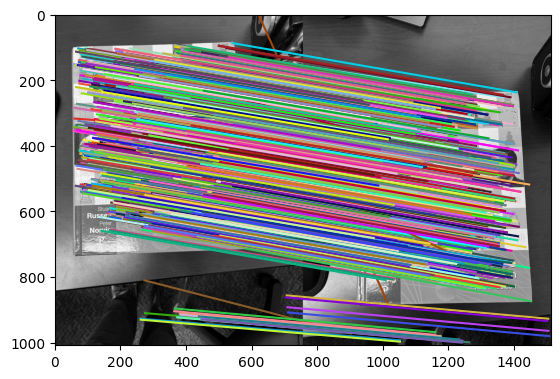

In [7]:
fig,ax = plt.subplots()
plot_matched_features(img1, img2, keypoints0=keypoints1, keypoints1=keypoints2, matches=matches12, ax=ax, only_matches=True)

Now let's compute the motion vector of each feature correspondence.

In [8]:
vecs = keypoints2[matches12[:,1]] - keypoints1[matches12[:,0]]

For simplicity's sake we will only keep the vectors with positive movement.

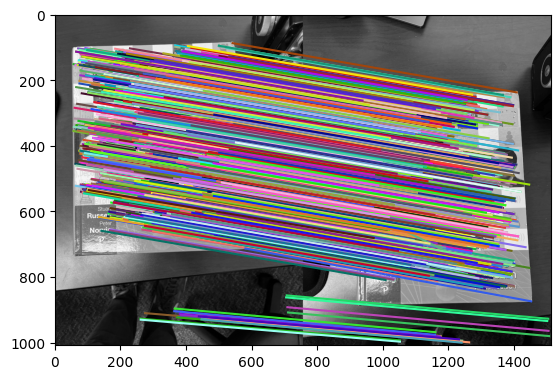

In [9]:
good = (vecs[:,1]>=0) & (vecs[:,0]>=0)
vecs = vecs[good]
matches12 = matches12[good]

fig,ax = plt.subplots()
plot_matched_features(img1, img2, keypoints0=keypoints1, keypoints1=keypoints2, matches=matches12, ax=ax, only_matches=True)

1. Now you will build a Hough accumulator to find the dominant motion in this data.

We are trying to estimate a 2D translation, so the Hough accumulator should have two dimensions.  The first dimension is for the Y component of the translation, and the second dimension is for the X dimension of the translation.

Make an accumulator of shape $500\times500$, filled with zeros.  Assume that each grid cell has a size of 1 pixel by 1 pixel.

In [11]:
accumulator = np.zeros((500, 500))


For each motion vector, add a 1 to the accumulator at the appropriate location.

*Note: It's okay to do this using a for loop.*

In [12]:
for x, y in vecs:
    accumulator[x,y] += 1

Show the accumulator as image using ```imshow```.

***Note: it will be mostly dark with one bright spot, since the motion vectors are tightly clustered.***

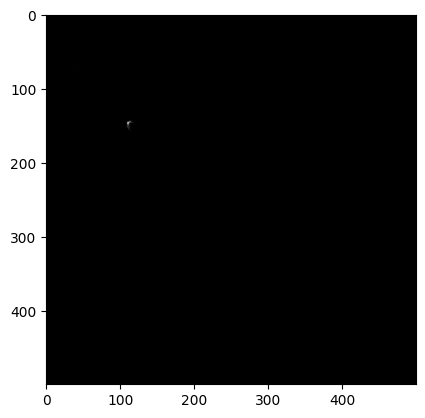

In [14]:
plt.imshow(accumulator, cmap="gray")

What is the maximum value in the accumulator?

In [18]:
accumulator.max()

106.0

Print the location of the maximum value in the accumulator.  This is the dominant motion vector.

***Hint: look at ```np.where```.***

In [19]:
np.where(accumulator == accumulator.max())

(array([147], dtype=int64), array([110], dtype=int64))

**Optional challenge question:** How would you change the resolution of the Hough accumulator (the size of each grid cell)?  For example, how could you make each grid cell have a size of $2\times2$ instead of $1\times1$ as it is now?

2. Now let's use RANSAC to find the dominant motion vector.

Here is the RANSAC process for this problem, using a fixed number of iterations:

- Repeat $N$ times:
  - Select a random motion vector from the list of motion vectors.  This is your "model."
  - Evaluate all motion vectors against the model using Euclidean distance.
  - Classify each motion vector as an inlier or outlier using a threshold of $\tau$.
  - Count the number of inliers.
- Keep the model with the highest number of inliers.

Use $N=1000$ and $\tau=5$.

I provided for you here a function to get the list of inliers for a motion vector, and a function to count the number of inliers.

After running RANSAC, print out the model with the most inliers, and show a plot of the inliers to that model.

*Hint: look at ```np.random.randint``` or ```np.random.choice``` for random sampling.*

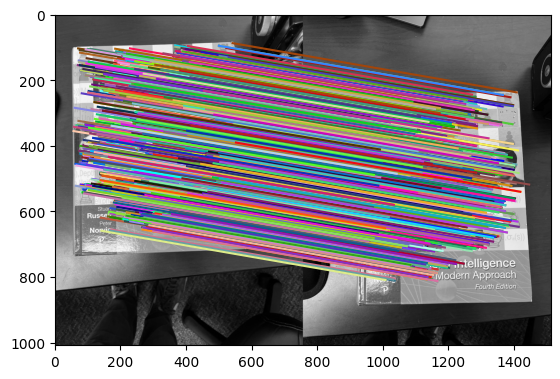

In [22]:
def get_inliers(vec,inlier_thresh=5):
    errs = np.sqrt( (vecs[:,0]-vec[0])**2 + (vecs[:,1]-vec[1])**2 )
    inliers = errs<inlier_thresh
    return inliers

def count_inliers(vec,inlier_thresh=5):
    inliers = get_inliers(vec,inlier_thresh)
    return np.count_nonzero(inliers)
N = 1000
threshold = 5
count = -1
best_model = None
for _ in range(N):
    model = vecs[np.random.randint(len(vecs))]
    num_inliers = count_inliers(model, threshold)
    if num_inliers > count:
        count = num_inliers
        best_model = model

fig, ax = plt.subplots()
inliers = get_inliers(best_model, threshold)
plot_matched_features(
      img1, img2,
      keypoints0=keypoints1, keypoints1=keypoints2,
      matches=matches12[inliers],
      ax=ax, only_matches=True,
)
